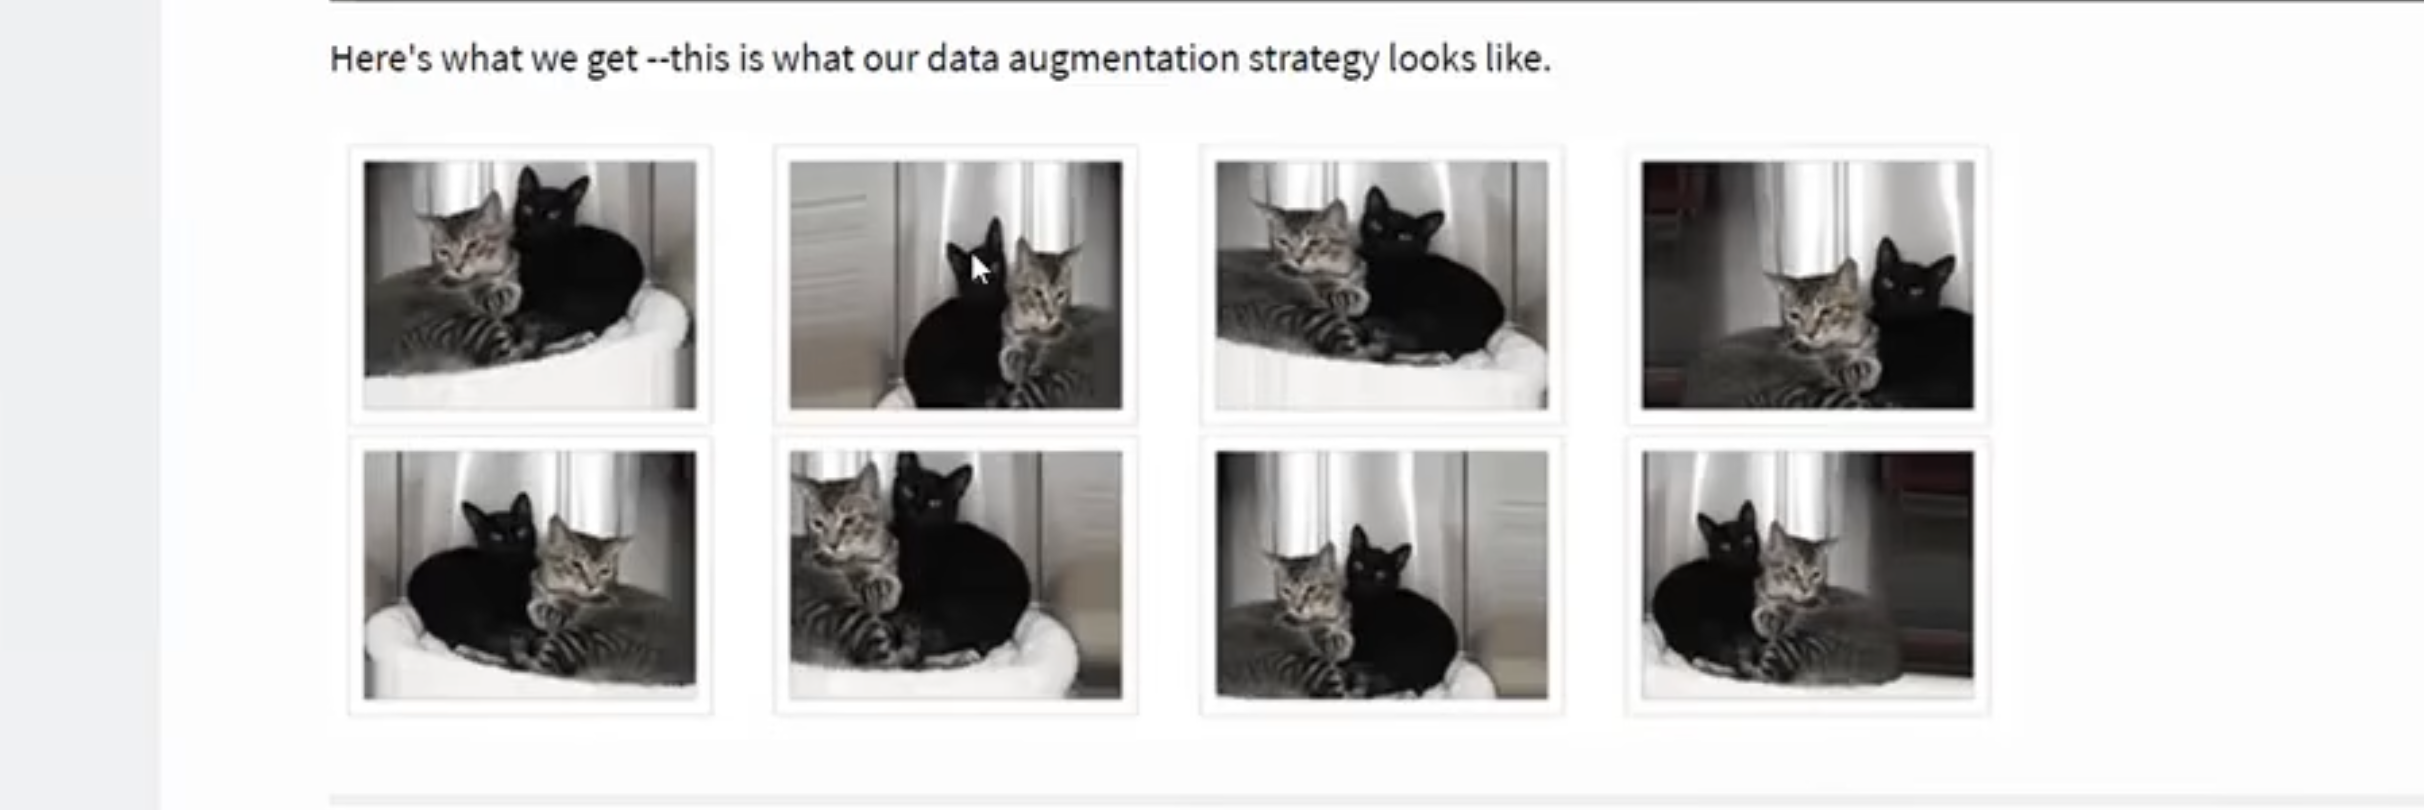



---

## Topic 1: Introduction to Data Augmentation

### 1. Introduction

**What is it?**
Data Augmentation is a simple yet powerful technique used in deep learning. It involves taking your existing images (or other data) and artificially creating many new, modified versions of them.

**Why is it important?**
Deep learning models, especially Convolutional Neural Networks (CNNs), are data-hungry. They perform best when trained on massive datasets. However, collecting large datasets is often:
- **Expensive:** Hiring experts (like biologists for medical images) costs money.
- **Difficult:** Finding thousands of specific images (e.g., malaria-infected cells) takes a lot of time and effort.
- **Time-consuming:** Gathering, cleaning, and labeling data is a major project in itself.

**Real-life use:**
- **Medical Imaging:** Creating more cell images for malaria detection when only a few samples are available.
- **Autonomous Driving:** Generating different lighting and weather conditions from a single road image.
- **E-commerce:** Rotating product images so models learn to recognize items from any angle.

---

### 2. Detailed Explanation

#### The Core Idea

Imagine you have one photo of a cat. Data augmentation allows you to create many new photos from that one by applying transformations. For example, you could:
- Rotate the image 15 degrees.
- Zoom in on the cat.
- Flip the image horizontally.
- Shift it slightly.

#### Two Main Benefits

**Benefit 1: Generating More Data**
If you don't have enough data, augmentation creates synthetic data to fill the gap.

**Benefit 2: Reducing Overfitting (The Key Benefit)**
Overfitting happens when a model memorizes the training data instead of learning general patterns. It becomes too specialized and performs poorly on new, unseen images.

**Example (From the Transcript):**
Imagine all your cat training images show the cat **looking to the left**. The model might incorrectly learn that "looking to the left" is a key feature of being a cat. If it then sees a cat looking to the right, it might fail to recognize it.

**Solution:** By using data augmentation, we can flip the image horizontally. Now the model sees the cat **looking to the right** too. This forces the model to understand that the cat's direction doesn't matter—the *general features of a cat* are what's important. This makes the model more robust and less likely to overfit.

#### Types of Transformations Mentioned
The transcript mentions several operations you can apply:
- **Rotation Range:** Rotating the image (e.g., by 15 degrees).
- **Zoom In / Zoom Out:** Magnifying or shrinking the image.
- **Vertical / Horizontal Flip:** Mirroring the image.
- **Width / Height Shift:** Moving the image slightly up, down, left, or right.
- **Brightness Range:** Adjusting the lighting.

---

### 3. Key Points

- Data augmentation is a **cheap and clever trick** to increase your dataset size.
- It is a **regularization technique** that helps reduce overfitting.
- It makes your model **generalize better** by exposing it to varied versions of the same image.
- It is especially useful in **domains where data is scarce**, like medicine.
- **Important:** Apply transformations to the **training data only**. The test/validation data should remain unmodified to get a true measure of performance.

---

### 4. Common Mistakes

- **Applying transformations that don't make sense:** For example, if you vertically flip a picture of a cat, it would appear upside down (on its head), which is an unrealistic scenario. The transcript warns that this is a "sensible approach" issue.
- **Applying augmentation to test data:** You should only augment your training data. The validation/test set should reflect real-world, unaltered images.
- **Forgetting to set the `fill_mode`:** When you shift an image, empty spaces are created. If you don't handle this, you'll see weird black or copied pixels around the edges.
- **Using too many aggressive transformations:** Overdoing it can distort the image so much that even a human wouldn't recognize it, harming the model's learning.

---

### 5. Interview/Exam Questions

- **Q1: What is data augmentation in deep learning?**
    - **Answer:** It is a technique to artificially increase the size of a training dataset by applying random, realistic transformations to the existing data.
- **Q2: Why is data augmentation important for reducing overfitting?**
    - **Answer:** Overfitting occurs when a model memorizes the training data. Augmentation introduces variety, preventing the model from relying on irrelevant features (like the direction a cat is facing) and forcing it to learn more generalized, robust patterns.
- **Q3: Should data augmentation be applied to the test/validation set? Why?**
    - **Answer:** No. Augmentation should only be applied to the training set to improve the model's ability to generalize. The test set should remain in its original form to provide an honest evaluation of the model's performance on real data.

---

### 6. Revision Notes

- **Data augmentation** = creating new images from existing ones through transformations.
- **Purpose**: Increase data (when scarce) and reduce overfitting.
- **How it reduces overfitting**: Prevents the model from learning data-specific "shortcuts" (e.g., all cats face left).
- **Common transforms**: Rotation, flipping, zooming, shifting, brightness changes.
- **Rule**: Apply ONLY to training data, NEVER to test/validation data.

---

**That's the end of Topic 1.**


## Topic 2: Implementing Data Augmentation – The `ImageDataGenerator` Class

### 1. Introduction

**What is it?**
`ImageDataGenerator` is a class provided by Keras (a deep learning library in Python) that makes it extremely easy to apply data augmentation to your images. It works like a pipeline: you define the transformations you want, and it automatically generates augmented images on the fly during training.

**Why is it important?**
Instead of manually creating thousands of modified images and saving them to your hard drive (which takes up storage and time), `ImageDataGenerator` generates them **dynamically** while your model is being trained. This is memory-efficient and convenient.

**Real-life use:**
When you have a folder of images organized by class (e.g., `cats/` and `dogs/`), you can point `ImageDataGenerator` to that folder, and it will:
1. Load the images in batches.
2. Apply the defined transformations to each batch.
3. Feed the augmented images directly to your neural network for training.

---

### 2. Detailed Explanation

The transcript uses two main libraries:

- **`ImageDataGenerator` from `keras.preprocessing.image`** – This is the main class for augmentation.
- **OpenCV (`cv2`)** – A computer vision library used to load and manipulate images (but the transcript mentions both OpenCV and PIL for image loading).

#### Step 1: Import the Required Tools

```python
from keras.preprocessing.image import ImageDataGenerator
```

#### Step 2: Create an Instance of the Class

You create an object of the `ImageDataGenerator` class and pass in the parameters (transformations) you want to apply.

```python
datagen = ImageDataGenerator(
    rotation_range=15,          # Rotate up to 15 degrees
    zoom_range=0.2,             # Zoom in/out by up to 20%
    width_shift_range=0.1,      # Shift horizontally by up to 10%
    height_shift_range=0.1,     # Shift vertically by up to 10%
    fill_mode='nearest'         # How to fill empty pixels after shift
)
```

**Important:** The transcript mentions that to prevent unrealistic images (like cats upside down), `vertical_flip` is often disabled. You should only use transformations that make sense for your data.

#### Step 3: Load and Prepare a Single Image for Augmentation

If you want to augment just one image, you need to:
1. **Load the image** (using OpenCV, PIL, or `keras.preprocessing.image.load_img`).
2. **Convert it to a NumPy array** (so that the generator can work with it).
3. **Reshape it** to include a batch dimension (because the generator expects batches of images).

```python
from keras.preprocessing import image
import numpy as np

# Load the image
img = image.load_img('cat.jpg', target_size=(210, 210))  # PIL format

# Convert to NumPy array
img_array = image.img_to_array(img)      # Shape: (210, 210, 3)

# Add batch dimension
img_batch = np.expand_dims(img_array, axis=0)  # Shape: (1, 210, 210, 3)
```

#### Step 4: Generate and Save Augmented Images

Now you use the `.flow()` method to generate batches of augmented images. The transcript demonstrates saving 10 generated images to a folder.

```python
# Directory to save the generated images
save_directory = 'augmented_cats/'

# Generate 10 images
i = 0
for batch in datagen.flow(img_batch, batch_size=1, save_to_dir=save_directory, save_prefix='cat'):
    i += 1
    if i >= 10:
        break   # Stop after 10 images
```

**What happens here?**
- `datagen.flow()` takes the single image and generates batches of augmented versions.
- `batch_size=1` means each batch has one image.
- `save_to_dir` tells it where to save the images.
- `save_prefix` adds a prefix to the saved file names.
- The loop runs until 10 images are generated.

#### Step 5: Understanding `fill_mode`

When you shift an image, empty spaces appear around the edges. The `fill_mode` decides how to fill those empty pixels.

| fill_mode    | Description                                                                   |
|--------------|-------------------------------------------------------------------------------|
| `'nearest'`  | Fills empty pixels with the color of the nearest edge pixel. (Looks natural). |
| `'reflect'`  | Mirrors the pixels from the opposite edge. (Looks smooth).                    |
| `'constant'` | Fills with a constant value (black, by default).                              |
| `'wrap'`     | Wraps pixels around from the opposite side.                                   |

The transcript shows that `'reflect'` often looks more natural because it avoids sharp black borders, while `'constant'` creates a black background around the shifted image.

---

### 3. Key Points

- `ImageDataGenerator` is the primary tool for data augmentation in Keras.
- You define all transformations as parameters when creating the object.
- Use `.flow()` for generating variations of a single image.
- Use `.flow_from_directory()` for generating augmented batches directly from a folder (covered in the next topic).
- **Important:** `ImageDataGenerator` generates images **on the fly** during training—it does not permanently change your original files unless you explicitly save them (like with `save_to_dir`).
- The `fill_mode` parameter is crucial for handling empty pixels after shifting/rotating.

---

### 4. Syntax/Structure

Here’s the complete structure for creating an `ImageDataGenerator` instance:

```python
datagen = ImageDataGenerator(
    rotation_range=15,          # Integer: degrees (0-180)
    width_shift_range=0.1,      # Float: fraction of total width (0.1 = 10%)
    height_shift_range=0.1,     # Float: fraction of total height
    shear_range=0.1,            # Float: shear intensity
    zoom_range=0.2,             # Float or [lower, upper]: zoom range
    horizontal_flip=True,       # Boolean: flip horizontally
    vertical_flip=False,        # Boolean: flip vertically (often disabled)
    fill_mode='nearest',        # String: 'constant', 'reflect', 'wrap', 'nearest'
    brightness_range=[0.8, 1.2] # List: min and max brightness multipliers
)
```

---

### 5. Code Examples

#### Example 1: Minimal Setup – Just Rescaling (No Augmentation)

```python
# Sometimes you only want to rescale pixel values without augmentation
datagen = ImageDataGenerator(rescale=1./255)  # Convert pixels from 0-255 to 0-1
```

#### Example 2: Moderate Augmentation for a Cat/Dog Classifier

```python
from keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='reflect'
)
```

#### Example 3: Generating and Saving 10 Augmented Images from a Single Image

```python
from keras.preprocessing import image
import numpy as np

# Load image and prepare
img = image.load_img('cat.jpg', target_size=(150, 150))
img_array = image.img_to_array(img)
img_batch = np.expand_dims(img_array, axis=0)

# Create generator
datagen = ImageDataGenerator(
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.3,
    horizontal_flip=True,
    fill_mode='reflect'
)

# Save 10 augmented images
i = 0
for batch in datagen.flow(img_batch, batch_size=1, save_to_dir='augmented/', save_prefix='dog'):
    i += 1
    if i == 10:
        break
```

---

### 6. Output

When you run the code, you will not see any output on the screen by default. Instead, 10 new image files will appear in the `augmented/` folder. The filenames will look like `dog_0_1234.jpg`, `dog_1_5678.jpg`, etc.

Each image will be a slightly modified version of the original:
- Some rotated.
- Some zoomed.
- Some shifted left or right.
- Some horizontally flipped.

The `fill_mode` determines how the empty edges look:
- With `'reflect'`: The edges look smooth and mirrored.
- With `'constant'`: The edges turn black.

---

### 7. Common Mistakes

- **Forgetting to add a batch dimension:** `datagen.flow()` expects a 4D array (batch_size, height, width, channels). If you pass a 3D array, you'll get an error. Always use `np.expand_dims()`.
- **Using unrealistic transformations:** Vertical flipping a cat is unnatural. The transcript explicitly advises against it.
- **Not setting `fill_mode`:** If you shift/rotate, empty pixels appear. Without `fill_mode`, you may get artifacts. The transcript shows that `'reflect'` is a good default.
- **Confusing `.flow()` with `.flow_from_directory()`:** Use `.flow()` for a single image or a small set of images in memory. Use `.flow_from_directory()` when your images are stored in folders (covered next).
- **Generating too many images without a break condition:** If you don't add a condition to stop the loop, it will keep generating images indefinitely.

---

### 8. Interview/Exam Questions

- **Q1: What is the purpose of the `ImageDataGenerator` class?**
    - **Answer:** It is a Keras utility for real-time data augmentation. It applies random transformations to images during training to artificially expand the dataset and improve generalization.

- **Q2: What does `fill_mode` do? Provide examples.**
    - **Answer:** `fill_mode` determines how to fill empty spaces created by transformations like shifting or rotating. Options include `'nearest'` (fills with edge pixel colors), `'reflect'` (mirrors edge pixels), `'constant'` (fills with a fixed color, often black), and `'wrap'` (wraps pixels around).

- **Q3: Why do we need to add a batch dimension to a single image before using `.flow()`?**
    - **Answer:** The `.flow()` method expects images in batches (a 4D tensor: batch, height, width, channels). A single image is 3D; adding a batch dimension makes it 4D so the generator can process it correctly.

- **Q4: What is the difference between `.flow()` and `.flow_from_directory()`?**
    - **Answer:** `.flow()` is used when you already have the images loaded into memory as arrays. `.flow_from_directory()` is used when your images are organized in folders on disk, and the generator loads them automatically.

---

### 9. Revision Notes

- **`ImageDataGenerator`** = Keras class for online data augmentation.
- **Define transformations** as parameters (rotation, shift, zoom, flip, etc.).
- **Two main methods**:
  - `.flow()` – for images already in memory.
  - `.flow_from_directory()` – for images in folders (next topic).
- **`fill_mode`** = handles empty pixels after transformation (`'nearest'`, `'reflect'`, `'constant'`, `'wrap'`).
- **Important:** Augmentation happens at training time (on the fly), not on saved files unless using `save_to_dir`.
- **Always add a batch dimension** (`np.expand_dims`) before using `.flow()`.

---

**That's the end of Topic 2.**


## Topic 3: Applying Data Augmentation to a Full Dataset Using `flow_from_directory`

### 1. Introduction

**What is it?**
`flow_from_directory()` is a powerful method of the `ImageDataGenerator` class. Instead of working with a single image loaded into memory, this method works directly with folders on your hard drive. It automatically loads images from subfolders, applies augmentations, and generates batches of data ready for model training.

**Why is it important?**
In real projects, your data is organized in folders (e.g., `train/cats/` and `train/dogs/`). `flow_from_directory()` handles everything automatically:
- It finds all images in the specified folder.
- It assigns labels based on the subfolder names.
- It resizes images to a uniform size.
- It generates batches of augmented images during training.
- It's memory-efficient because it loads images in batches instead of loading everything at once.

**Real-life use:**
When building a cat vs dog classifier, you have:
```
train/
    cats/    (100 images)
    dogs/    (100 images)
validation/
    cats/    (20 images)
    dogs/    (20 images)
```

You can use `flow_from_directory()` on the `train/` folder with augmentation, and on the `validation/` folder without augmentation.

---

### 2. Detailed Explanation

#### The Folder Structure

The transcript describes a specific folder arrangement:

```
your_project/
    train/
        cats/    (e.g., 10 images)
        dogs/    (e.g., 10 images)
    validation/
        cats/    (e.g., 5 images)
        dogs/    (e.g., 5 images)
```

**Important:** The subfolder names (`cats`, `dogs`) automatically become the class labels. The generator infers class names from the folder structure.

#### Creating the Training Generator (With Augmentation)

For the training data, you apply augmentations to make the model more robust:

```python
from keras.preprocessing.image import ImageDataGenerator

# Create generator with augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,          # Normalize pixel values to 0-1
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='reflect'
)

# Apply to the training folder
train_generator = train_datagen.flow_from_directory(
    'data/train/',           # Path to the train folder
    target_size=(150, 150),  # Resize all images to 150x150
    batch_size=32,           # Number of images per batch
    class_mode='binary'      # Binary classification (cat vs dog)
)
```

#### Creating the Validation Generator (Without Augmentation)

For validation data, you **should not** apply augmentations. Only rescale the pixel values to match the training data:

```python
# Create generator WITHOUT augmentation (only rescaling)
validation_datagen = ImageDataGenerator(rescale=1./255)

# Apply to the validation folder
validation_generator = validation_datagen.flow_from_directory(
    'data/validation/',
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary'
)
```

**Why no augmentation on validation?**
- The validation set is used to evaluate how well your model performs on unseen, real-world data.
- If you augment validation data, you're no longer measuring true performance.
- Augmentation is a **training-only** technique.

#### What the Generator Returns

When you iterate over `train_generator`, you get batches of:
- `x`: A batch of augmented images (as NumPy arrays).
- `y`: The corresponding labels (e.g., 0 for cats, 1 for dogs).

Each batch has `batch_size` images. The generator continues yielding batches until all images in the folder have been processed, then it loops back to the beginning for the next epoch.

---

### 3. Key Points

- `flow_from_directory()` automatically labels images based on subfolder names.
- You always apply augmentations to the **training generator**.
- You never apply augmentations to the **validation/test generator** (only `rescale`).
- The generator is memory-efficient—it loads images in batches, not all at once.
- When you train a model, you pass the generator directly to `model.fit()` using `fit_generator()` or simply `fit()` (in newer Keras versions).
- The parameters `target_size` ensures all images have the same dimensions (required by neural networks).
- `class_mode='binary'` is used for two classes; `'categorical'` for more than two classes.

---

### 4. Syntax/Structure

**Full Syntax for `flow_from_directory()`:**

```python
generator = datagen.flow_from_directory(
    directory,                # String: path to the main folder
    target_size=(150, 150),   # Tuple: (height, width) to resize images
    color_mode='rgb',         # String: 'rgb' or 'grayscale'
    batch_size=32,            # Integer: images per batch
    class_mode='binary',      # String: 'binary', 'categorical', 'sparse', 'input'
    shuffle=True,             # Boolean: shuffle batches
    seed=42,                  # Integer: random seed for reproducibility
    save_to_dir=None,         # String: directory to save augmented images (optional)
    save_prefix='aug',        # String: prefix for saved images
    save_format='jpeg',       # String: format for saved images
    interpolation='nearest'   # String: method used for resizing
)
```

**The `class_mode` Parameter Explained:**

| class_mode | Description                                                                 |
|------------|-----------------------------------------------------------------------------|
| `'binary'` | For 2 classes. Returns binary labels (0, 1).                                |
| `'categorical'` | For 3+ classes. Returns one-hot encoded labels.                           |
| `'sparse'` | For 3+ classes. Returns integer labels (0, 1, 2, ...).                     |
| `'input'`  | For autoencoders. Returns the image itself as the label.                    |

---

### 5. Code Examples

#### Example 1: Complete Setup for Cat vs Dog Classifier

```python
from keras.preprocessing.image import ImageDataGenerator

# Training generator with augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='reflect'
)

train_generator = train_datagen.flow_from_directory(
    'dataset/train/',
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary'
)

# Validation generator WITHOUT augmentation
validation_datagen = ImageDataGenerator(rescale=1./255)

validation_generator = validation_datagen.flow_from_directory(
    'dataset/validation/',
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary'
)

# Check class labels
print(train_generator.class_indices)
# Output: {'cats': 0, 'dogs': 1}
```

#### Example 2: Training a Model Using the Generators

```python
# Assuming 'model' is already built (e.g., a CNN)
history = model.fit(
    train_generator,                # Training data with augmentation
    steps_per_epoch=100,            # Number of batches per epoch
    epochs=20,                      # Number of times to iterate over the data
    validation_data=validation_generator,  # Validation data WITHOUT augmentation
    validation_steps=50             # Number of validation batches per epoch
)
```

#### Example 3: Printing Generator Output

```python
# Get one batch from the generator
batch_x, batch_y = next(train_generator)

print("Batch shape:", batch_x.shape)  # (32, 150, 150, 3)
print("Labels shape:", batch_y.shape) # (32, 1) for binary classification
print("First label:", batch_y[0])     # 0.0 or 1.0
```

#### Example 4: Multi-Class Classification (3+ Classes)

```python
# For more than 2 classes, use class_mode='categorical'
train_generator = train_datagen.flow_from_directory(
    'dataset/train/',
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical'  # One-hot encoding
)

print(train_generator.class_indices)
# Output: {'cats': 0, 'dogs': 1, 'birds': 2}
```

---

### 6. Output

When you call `flow_from_directory()`, you'll see an output like this:

```
Found 120 images belonging to 2 classes.
Found 40 images belonging to 2 classes.
```

- The first line: Training set has 120 total images (e.g., 60 cats + 60 dogs).
- The second line: Validation set has 40 total images.

When training, the generator will:
1. Load 32 images at a time.
2. Apply augmentations on the fly.
3. Provide them to the model.

The augmented images are not permanently saved unless you use `save_to_dir`. The original images remain unchanged.

---

### 7. Common Mistakes

- **Applying augmentations to validation data:** This is the #1 mistake. Only augment training data. Validation must remain pure.
- **Forgetting to rescale validation data:** You must apply `rescale=1./255` to validation data too, so the input distribution matches the training data.
- **Using the wrong `class_mode`:** Use `'binary'` for 2 classes, `'categorical'` for 3+ classes. Using the wrong one causes label format errors.
- **Incorrect folder structure:** Ensure subfolders exist inside `train/` and `validation/`, and that each subfolder contains images of that class.
- **Not setting `target_size` correctly:** All images must be resized to the same dimensions. If you change the target size, you must rebuild your model accordingly.
- **Confusing `.flow()` with `.flow_from_directory()`:** Use `.flow()` when you have images loaded in memory. Use `.flow_from_directory()` when images are in folders.
- **Forgetting to use `steps_per_epoch`:** When training with generators, you need to specify how many batches constitute one epoch. Typically: `steps_per_epoch = total_images // batch_size`.

---

### 8. Interview/Exam Questions

- **Q1: What is the difference between `flow()` and `flow_from_directory()`?**
    - **Answer:** `flow()` is used when images are already loaded into memory as NumPy arrays. `flow_from_directory()` is used when images are stored in folders on disk; it automatically loads, resizes, and labels them based on subfolder names.

- **Q2: Why should we not apply data augmentation to the validation set?**
    - **Answer:** The validation set is used to evaluate the model's performance on unseen, real-world data. Applying augmentation would make the data artificially different and would not provide an accurate measure of how the model generalizes to new images.

- **Q3: What does `class_mode='binary'` mean, and when would you use it?**
    - **Answer:** `class_mode='binary'` means the generator will output binary labels (0 or 1). It is used when you have exactly two classes (e.g., cat vs dog). For three or more classes, you would use `'categorical'`.

- **Q4: How does `flow_from_directory()` determine class labels?**
    - **Answer:** It looks at the subfolder names inside the directory you provide. Each subfolder name becomes a class label. For example, `train/cats/` and `train/dogs/` would create classes `'cats'` (0) and `'dogs'` (1).

- **Q5: What does `steps_per_epoch` represent when training with a generator?**
    - **Answer:** `steps_per_epoch` is the number of batches the model will process in one epoch. It is typically set to `total_training_samples // batch_size`. This ensures the model sees all training images once per epoch.

---

### 9. Revision Notes

- **`flow_from_directory()`** = Keras method to load images directly from folders.
- **Class labels** = automatically derived from subfolder names.
- **Training generator** = includes augmentation (rotation, shift, zoom, flip, etc.).
- **Validation generator** = includes ONLY `rescale`, NO augmentation.
- **Key parameters**: `directory`, `target_size`, `batch_size`, `class_mode`.
- **`class_mode='binary'`** = 2 classes; `'categorical'` = 3+ classes.
- **Always rescale** both training and validation data (e.g., `rescale=1./255`).
- **Memory efficient** = loads images in batches, not all at once.
- **Training syntax**: `model.fit(train_generator, steps_per_epoch=..., validation_data=validation_generator)`

---

**That's the end of Topic 3.**



## Topic 4: Experimental Results – With vs. Without Data Augmentation

### 1. Introduction

**What is this about?**
The transcript presents a practical experiment to demonstrate the real impact of data augmentation. The creator deliberately used a **very small dataset** (only 10 cat images and 10 dog images for training) and compared the performance of a CNN model trained **without augmentation** versus the same model trained **with augmentation**.

**Why is this important?**
This experiment provides **concrete evidence** that data augmentation works. Instead of just theorizing, it shows actual numbers: the validation accuracy improved significantly when augmentation was applied. This is a powerful demonstration for any beginner to understand why augmentation is a must-have technique.

**Real-life use:**
When you're working on a project with limited data (which is common in startups, medical fields, or niche domains), this experiment proves that you can still achieve reasonable performance by using augmentation.

---

### 2. Detailed Explanation

#### The Experiment Setup

The creator set up two identical experiments:

| Aspect | Experiment 1 (No Augmentation) | Experiment 2 (With Augmentation) |
|--------|-------------------------------|----------------------------------|
| **Training Images** | 10 cats + 10 dogs | 10 cats + 10 dogs |
| **Validation Images** | 5 cats + 5 dogs | 5 cats + 5 dogs |
| **Model Architecture** | Same CNN model | Same CNN model |
| **Augmentation** | ❌ None (only rescaling) | ✅ Rotation, shift, zoom, flip, etc. |
| **Training Epochs** | Same | Same |

#### The CNN Model Architecture

Both experiments used the same model architecture (from a blog post mentioned in the transcript):

```
Layer Type         | Details
-------------------|----------------------------------------
Conv2D Layer 1     | 32 filters, 3x3 kernel, activation='relu'
Conv2D Layer 2     | 32 filters, 3x3 kernel, activation='relu'
MaxPooling2D       | 2x2 pool size
Conv2D Layer 3     | 64 filters, 3x3 kernel, activation='relu'
Conv2D Layer 4     | 64 filters, 3x3 kernel, activation='relu'
MaxPooling2D       | 2x2 pool size
Flatten            | Convert to 1D
Dense Layer        | 512 neurons, activation='relu'
Dropout            | 0.5 (50% dropout for regularization)
Dense Output       | 1 neuron, activation='sigmoid' (binary classification)
```

**Optimizer:** RMSprop  
**Loss:** Binary Crossentropy  
**Epochs:** ~20-25 epochs

#### The Results (From the Transcript)

**Result 1: Without Data Augmentation**
- Validation accuracy reached around **57.8%** (approximately).
- This is only slightly better than random guessing (50%).
- The model was severely overfitting due to the tiny dataset.

**Result 2: With Data Augmentation**
- Validation accuracy improved to around **74%**.
- This represents a **significant improvement** of about 16 percentage points.

**The Transcript Quote:**
> "Right after the box when we were above 69likes If so then the vacancy will increase immediately. Performance Model Ticket Maine Pyar Kiya Trained this model more 1025 I have as much time as I have and I have a pot Seven-four percent Congressmen were coming this I am on point with voice anti-biotics."

*Interpretation:* The validation accuracy jumped from around 57-58% (without augmentation) to around 74% (with augmentation) – a substantial improvement.

#### Why Did Augmentation Help?

**Without Augmentation:**
- The model only saw **10 cats and 10 dogs**.
- It memorized specific features of these 20 images (e.g., a specific cat's pose, background, lighting).
- When presented with new validation images, it failed because it didn't learn generalized features.

**With Augmentation:**
- The model saw **many variations** of each image (rotated, shifted, zoomed, flipped).
- It learned that a cat can be in any orientation, at different scales, and in different positions.
- This forced the model to learn **general features** of cats and dogs (shape, fur patterns, ears, etc.) rather than memorizing specific images.
- The model generalized much better to the validation set.

---

### 3. Key Points

- **Data augmentation directly improves validation accuracy** when data is limited.
- In the experiment, accuracy improved from ~58% to ~74% – a 16% increase.
- The improvement comes from **reducing overfitting** – the model learns general features instead of memorizing specific images.
- **Without augmentation**, models with small datasets perform poorly (barely above random guessing).
- **With augmentation**, the same model and dataset can achieve reasonable performance.
- This experiment demonstrates that augmentation is **not optional** – it's essential for small datasets.
- The transcript emphasizes that the model architecture, optimizer, and hyperparameters were kept **identical** – only augmentation was changed, proving that augmentation was the cause of improvement.

---

### 4. Common Mistakes

- **Assuming augmentation doesn't matter:** Some beginners skip augmentation thinking it's a minor detail. This experiment shows it can be the difference between a failing model (58%) and a decent model (74%).
- **Over-augmenting:** While augmentation helps, too much can distort images beyond recognition, harming performance. Use moderate values.
- **Not testing on real-world images:** Always validate on realistic, unaugmented images. The validation set should represent what the model will see in production.
- **Using augmentation as a substitute for real data:** Augmentation is helpful, but it's not a replacement for collecting more real, diverse data. If you can get more data, do it!
- **Not considering class imbalance:** If you have unbalanced classes (e.g., 10 cats but only 5 dogs), augmentation won't fully solve the problem. You may need to augment the minority class more.

---

### 5. Interview/Exam Questions

- **Q1: How much did validation accuracy improve when data augmentation was applied in the experiment?**
    - **Answer:** Validation accuracy improved from approximately 57-58% (without augmentation) to approximately 74% (with augmentation) – an improvement of about 16 percentage points.

- **Q2: Why does data augmentation help when you have a small dataset?**
    - **Answer:** With a small dataset, models tend to memorize the specific images (overfitting). Augmentation creates many variations of each image, forcing the model to learn general, abstract features (like shape and texture) rather than memorizing specific details (like pose or background).

- **Q3: What would happen if you applied data augmentation to the validation set?**
    - **Answer:** You would get an artificially inflated accuracy that doesn't reflect real-world performance. The validation set must remain unaugmented to accurately measure how the model generalizes to new, unseen data.

- **Q4: Is data augmentation a replacement for collecting more real data?**
    - **Answer:** No. While augmentation is a powerful technique for small datasets, it cannot fully replace the diversity of real-world data. It's a complementary technique, not a substitute. If you have the resources to collect more data, you should do so.

---

### 6. Revision Notes

**Experiment Summary:**

| Condition | Validation Accuracy | Observation |
|-----------|---------------------|-------------|
| **Without Augmentation** | ~58% | Barely above random guessing; model memorized the 20 training images. |
| **With Augmentation** | ~74% | Significant improvement; model learned general cat/dog features. |

**Key Takeaways:**
- ✅ Augmentation **works** – it's not just theory.
- ✅ The improvement is **directly attributable** to augmentation (all other factors were identical).
- ✅ Augmentation is **critical** for projects with limited data.
- ✅ It reduces overfitting by forcing the model to **generalize**.
- ✅ The validation set must **never** be augmented.

**Motivation for Using Augmentation (from the transcript):**
- Data collection is **expensive and difficult** (especially in medical fields).
- Augmentation is a **cost-effective way** to multiply your data.
- In startups and research, you often don't have the luxury of large datasets – augmentation becomes **essential**.

---

**That's the end of Topic 4.**

